# A Sinkhorn-type Algorithm for Constrained Optimal Transport

**Implementation and Experiments — Homework Project by Sergei Gerasimov**

> *Based on:* "A Sinkhorn-type Algorithm for Constrained Optimal Transport."

---

## 1. Problem Statement

### 1.1 Standard Optimal Transport

Classical (discrete) optimal transport seeks the cheapest way to move mass from a source distribution $r \in \Delta^n$ to a target distribution $c \in \Delta^m$, where cost matrix $C_{ij}$ measures the expense of sending one unit from source $i$ to target $j$:

$$
\min_{P \in U(r,c)} \langle C, P \rangle
$$

where the *transport polytope* is

$$
U(r,c) = \{P \geq 0 \mid P\mathbf{1} = r,\; P^\top\mathbf{1} = c\}.
$$

### 1.2 Linearly Constrained OT

The paper extends this to problems with additional **linear constraints** on $P$, motivated by applications such as fair allocation, demographic parity, and shape-preserving transport:

$$
\min_{P \in U(r,c)} \langle C, P \rangle
\quad \text{subject to} \quad
\langle D_k, P \rangle \geq 0,\; k=1,\ldots,K
\qquad
\langle D_\ell, P \rangle = 0,\; \ell=1,\ldots,L.
$$

Each constraint matrix $D_k \in \mathbb{R}^{n \times m}$ encodes a statistical condition on the coupling $P$.  For example, setting $D_k = (\text{group A rows}) - (\text{group B rows})$ encodes a demographic parity requirement.

### 1.3 Entropic Relaxation (Eq. 5)

Direct LP solvers scale as $O(n^3)$.  The paper instead uses an **entropic relaxation** that introduces slack variables $s_k \geq 0$ for each inequality:

$$
\min_{P, s_1,\ldots,s_K}\; \langle C, P \rangle + \frac{1}{\eta}\, H(P, s_1, \ldots, s_K)
$$
$$
\text{s.t. } D_k \cdot P = s_k \;(k=1..K),\quad D_\ell \cdot P = 0 \;(\ell=1..L),
$$

where $H$ is the (negative) joint entropy and $\eta > 0$ is a sharpness parameter.  As $\eta \to \infty$ the solution converges to the LP optimum; small $\eta$ gives a smoother, more diffuse plan.

## 2. Dual Formulation

### 2.1 Dual Variables

Taking Lagrangian duals of the marginal constraints and the linear constraints introduces three sets of dual variables:

| Variable | Shape | Meaning |
|----------|-------|---------|
| $x \in \mathbb{R}^n$ | $n$ | Row (source) potentials |
| $y \in \mathbb{R}^m$ | $m$ | Column (target) potentials |
| $a \in \mathbb{R}^{K+L}$ | $K+L$ | Constraint dual variables |

### 2.2 The Dual Objective (Eq. 7)

The dual function to **maximise** is:

$$
f(x,y,a) =
-\frac{1}{\eta}\sum_{ij} P^{\circ}_{ij}
+ \sum_i x_i r_i + \sum_j y_j c_j
-\frac{1}{\eta}\sum_{k=1}^{K} \exp(-\eta a_k - 1),
$$

where the *intermediate transport plan* is
$$
P^{\circ}_{ij} = \exp\!\left(\eta\bigl(-C_{ij} + {\textstyle\sum_m} a_m (D_m)_{ij}
+ x_i + y_j\bigr) - 1\right).
$$

The $-1$ exponent normalises the plan so that at optimality $\sum_{ij} P^{\circ}_{ij} = \sum_i r_i = 1$.

### 2.3 Gradients (Eq. 8)

The gradient of $f$ with respect to each block has a clean form:

$$
\nabla_x f = r - P^{\circ}\mathbf{1}, \qquad
\nabla_y f = c - (P^{\circ})^\top\mathbf{1},
$$

$$
\frac{\partial f}{\partial a_k} = \exp(-\eta a_k - 1) - \langle P^{\circ}, D_k \rangle
\;(\text{inequality}), \qquad
\frac{\partial f}{\partial a_{K+\ell}} = -\langle P^{\circ}, D_\ell \rangle
\;(\text{equality}).
$$

Setting $\nabla f = 0$ recovers the KKT conditions of the primal problem. Note that $\nabla_x f = 0 \Leftrightarrow P^{\circ}\mathbf{1} = r$, i.e., the row marginal is satisfied — exactly what a Sinkhorn x-update achieves in one step.

## 3. Algorithm 1

### 3.1 High-level Structure

The key insight is that $f$ is **separately concave** in each of $x$, $y$, and $a$, which motivates a block coordinate ascent strategy.  However, the $x$ and $y$ updates admit a closed-form (Sinkhorn step), while the $a$-update requires a Newton solve.

```
Algorithm 1  Constrained Sinkhorn
─────────────────────────────────────────────────────────────
Input:  C, r, c, {D_k}, {D_ℓ}, η, tol
Init:   x = 0, y = 0, a = 0

repeat
  ┌─ Sinkhorn block (n_sinkhorn steps) ──────────────────
  │  Build  C_eff  = C − Σ_m a_m D_m
  │  for i in 1..n_sinkhorn:
  │      x ← ε·log r − ε·lse_j[(y_j − C_eff_ij)/ε]   (row update)
  │      y ← ε·log c − ε·lse_i[(x_i − C_eff_ij)/ε]   (col update)
  └───────────────────────────────────────────────────────
  ┌─ Newton a-update ─────────────────────────────────────
  │  Solve  H·Δz = −∇f_aug  for Δ(a,t)
  │  a ← a + α·Δa,   t ← t + α·Δt
  └───────────────────────────────────────────────────────
  x ← x + t          (recentre row potentials)
until ‖∇f‖₁ < tol
```

### 3.2 The Sinkhorn Sub-steps

The $x$ and $y$ updates correspond to classical log-domain Sinkhorn scaling on the **effective cost** $C_{\text{eff}} = C - \sum_m a_m D_m$. Importantly, the update for $x$ does **not** include $x$ in the LSE — only $y$ appears:

$$
x_i \leftarrow \varepsilon (\log r_i +1 )- \varepsilon \operatorname{lse}_j
\!\left[\frac{y_j - (C_{\text{eff}})_{ij}}{\varepsilon}\right]
$$

This *one-sided* form guarantees that after a single $x$-step, $\sum_j P^{\text{NO-OFFSET}}_{ij} = r_i$ **exactly**, not just in the limit. (This is the semantics implemented by `Geometry.update_potential` in OTT-JAX.)

### 3.3 The Newton a-update

The constraint dual variables $a$ (and a recentering scalar $t$) are updated by Newton's method on the augmented dual

$$
f_{\text{aug}}(a) = \max_t\; f(x + t \cdot \mathbf{1},\; y,\; a).
$$

The joint $(a,t)$ gradient is:

$$
\nabla_a f_{\text{aug}} \text{ (see §2.3)}, \qquad
\nabla_t f_{\text{aug}} = \sum_i r_i - \sum_{ij} P^{\circ}_{ij}.
$$

The Hessian $H \in \mathbb{R}^{(M+1)\times(M+1)}$ (Eq. 27) is negative semi-definite (concave function), so Newton's method maximises $f_{\text{aug}}$. After the Newton step, $x \leftarrow x + t$ recentres the row potentials.

### 3.4 Eta Schedule (Algorithm 3)

High $\eta$ gives sharp solutions close to the LP optimum but converges slowly.  The paper proposes a **doubling schedule**: solve at $\eta_1 < \eta_2 < \cdots$ with warm starts, which dramatically reduces total iterations.

| $\eta$ level | Purpose |
|-------------|---------|
| Small ($\eta = 2$) | Fast, coarse convergence |
| Doubling | Progressively sharper plan |
| Large ($\eta = 50$) | Near-LP solution |

## 4. Integration with OTT-JAX

We use the `ott.geometry.geometry.Geometry` class as our numerical backend. This decouples the linear-algebra kernel (LSE, cost matrix) from the algorithm logic and enables JAX JIT compilation.

### Notation mapping

| Paper | OTT-JAX `Geometry` | Shape |
|-------|-------------------|-------|
| $x$ (row dual) | `f` potential | `(n,)` |
| $y$ (col dual) | `g` potential | `(m,)` |
| $\varepsilon = 1/\eta$ | `geom.epsilon` | scalar |
| $C_{\text{eff}}$ | `geom.cost_matrix` | `(n,m)` |
| Sinkhorn x-step | `geom.update_potential(f,g,log_r, axis=1)` | |
| Sinkhorn y-step | `geom.update_potential(f,g,log_c, axis=0)` | |

### Transport plan convention

There are two conventions in play:

- **`P_NO_OFFSET`** $= \exp(\text{center}/\varepsilon)$  — returned by `_transport_plan`; row sums equal $r$ at Sinkhorn convergence.
- **`P_paper`** $= \exp(\text{center}/\varepsilon - 1)$  — the paper's plan used in the dual objective and the Newton a-update.

The $-1$ offset appears **only** in `_dual_obj_and_grad` and `_a_update`. At optimality, the Newton step drives $t \to 1/\eta$ which makes $P^{\circ}\mathbf{1} = r$ as well.

### Fallback geometry

When OTT-JAX is not available, `_FallbackGeometry` provides an identical NumPy/SciPy implementation.  This lets the code run in any environment without a JAX installation.

## 5. Implementation

### 5.1 Imports

Standard scientific stack plus an optional OTT-JAX import.

In [1]:
from __future__ import annotations
import numpy as np
from scipy.special import logsumexp as sp_lse
from scipy.linalg import solve as sp_solve, LinAlgError
from dataclasses import dataclass
from typing import Optional

try:
    import jax.numpy as jnp
    from ott.geometry.geometry import Geometry
    _OTT_AVAILABLE = True
    print('OTT-JAX available — using JAX backend')
except ImportError:
    _OTT_AVAILABLE = False
    print('OTT-JAX not found — using NumPy fallback')


OTT-JAX available — using JAX backend


### 5.2 Part 1 — Core Building Blocks

This cell implements five components:

1. **`_FallbackGeometry`** — NumPy drop-in for `ott.geometry.Geometry`. Its `update_potential` uses a *one-sided* LSE: when updating $x$, only $y$ appears in the sum (not $x$ itself). This is the mathematically correct Sinkhorn step and matches OTT-JAX's implementation.

2. **`_make_effective_geom(C, D_list, a, η)`** — Builds a Geometry with effective cost $C_{\text{eff}} = C - \sum_m a_m D_m$. This is called at every outer iteration when $a$ changes.

3. **`_transport_plan(geom, x, y)`** — Returns $P_{\text{NO-OFFSET}} = \exp(\text{center}/\varepsilon)$ (no $-1$). Row sums equal $r$ at Sinkhorn convergence.

4. **`_dual_obj_and_grad(C, D_ineq, D_eq, r, c, η, x, y, a)`** — Evaluates $f(x,y,a)$ and all three gradient blocks. This is the **only** place $P^{\circ} = \exp(\text{center}/\varepsilon - 1)$ is used.

5. **`_x_update` / `_y_update`** — Thin wrappers around `geom.update_potential` that enforce the correct axis and pass $\log r$ or $\log c$.

In [2]:
"""
==============================
Part 1 — Core building blocks for Algorithm 1 of
"A Sinkhorn-type Algorithm for Constrained Optimal Transport"

Sinkhorn update convention
--------------------------
Standard log-domain Sinkhorn alternates:

    x_i  ←  ε·log r_i  −  ε·lse_j[(y_j − C_ij)/ε]        (row update)
    y_j  ←  ε·log c_j  −  ε·lse_i[(x_i − C_ij)/ε]        (col update)

After an x-update:  sum_j exp((x_i + y_j − C_ij)/ε) = r_i  exactly.
This is the form OTT-JAX's Geometry.update_potential implements:
    new_f = ε·log_marginal − apply_lse_kernel(g_only, C, ε, axis=1)
where the LSE over j uses ONLY g (not f).

Transport plan convention
-------------------------
_transport_plan returns  P_NO_OFFSET = exp(center/ε)
where center_ij = x_i + y_j − C_eff_ij.  Its row sums equal r at convergence.

The paper's plan  P_paper = exp(center/ε − 1) = e^{-1}·P_NO_OFFSET
is used ONLY inside _dual_obj_and_grad (for f(x,y,a) and ∇f).
The t variable in the a-update re-normalises P_paper back to sum = Σr.

Cells:
  1. Imports
  2. _make_effective_geom      -- effective cost + Geometry factory
  3. _transport_plan           -- P_NO_OFFSET = exp(center/ε)
  4. _dual_obj_and_grad        -- f(x,y,a) and ∇f  using P_paper
  5. _x_update / _y_update     -- standard log-Sinkhorn steps
"""

from __future__ import annotations

# ── Cell 1: Imports ─────────────────────────────────────────────────────────────
import numpy as np
from scipy.special import logsumexp as sp_lse

try:
    import jax.numpy as jnp          # noqa: F401  — available to callers if present
except ImportError:
    pass

try:
    from ott.geometry.geometry import Geometry   # type: ignore
    _OTT_AVAILABLE = True
except ImportError:
    _OTT_AVAILABLE = False


# ── Cell 2: Geometry factory ─────────────────────────────────────────────────────

class _FallbackGeometry:
    """
    Drop-in for ott.geometry.geometry.Geometry when OTT-JAX is not installed.

    Implements the exact API used by the algorithm:
        _center(f, g)                          → f_i + g_j − C_ij
        apply_lse_kernel(f, g, eps, axis)      → ε·LSE along axis
        update_potential(f, g, log_marg, axis) → standard log-Sinkhorn step

    update_potential semantics (matching OTT-JAX):
        axis=1  →  new_f_i = ε·log_r_i − ε·lse_j[(g_j − C_ij)/ε]
        axis=0  →  new_g_j = ε·log_c_j − ε·lse_i[(f_i − C_ij)/ε]

    The potential being UPDATED does not appear in the LSE.
    This is the standard Sinkhorn scaling in log-domain and guarantees
    that after each step the corresponding marginal of P equals the target.
    """

    def __init__(self, cost_matrix: np.ndarray, epsilon: float):
        self.cost_matrix = np.asarray(cost_matrix, np.float64)
        self.epsilon = float(epsilon)

    def _center(self, f: np.ndarray, g: np.ndarray) -> np.ndarray:
        """f_i + g_j − C_ij   (identical to OTT-JAX Geometry._center)"""
        return f[:, None] + g[None, :] - self.cost_matrix

    def apply_lse_kernel(
        self,
        f: np.ndarray,
        g: np.ndarray,
        eps: float,
        vec=None,
        axis: int = 0,
    ) -> tuple:
        """
        axis=1 → result_i = ε·logsumexp_j[(f_i + g_j − C_ij)/ε]
        axis=0 → result_j = ε·logsumexp_i[(f_i + g_j − C_ij)/ε]
        Returns (lse_scaled, signs) matching OTT-JAX convention.
        Used for diagnostics and the dual objective; NOT used inside
        update_potential (which uses a one-sided lse for correctness).
        """
        M = self._center(f, g) / eps
        if vec is None:
            lse = sp_lse(M, axis=axis)
        else:
            b = vec[:, None] if axis == 0 else vec[None, :]
            lse = sp_lse(M, b=b, axis=axis)
        return eps * lse, np.ones_like(lse)

    def update_potential(
        self,
        f: np.ndarray,
        g: np.ndarray,
        log_marginal: np.ndarray,
        iteration=None,   # unused; present for OTT-JAX API compatibility
        axis: int = 0,
    ) -> np.ndarray:
        """
        Standard log-domain Sinkhorn update.

        axis=1  →  new_f_i = ε·log_r_i − ε·lse_j[(g_j − C_ij)/ε]
        axis=0  →  new_g_j = ε·log_c_j − ε·lse_i[(f_i − C_ij)/ε]

        The potential being updated (f for axis=1, g for axis=0) does NOT
        appear in the LSE — only the OTHER potential does.  This ensures:
            sum_j exp((f_new_i + g_j − C_ij)/ε) = r_i   (after axis=1 step)
            sum_i exp((f_i + g_new_j − C_ij)/ε) = c_j   (after axis=0 step)
        """
        eps = self.epsilon
        C   = self.cost_matrix

        if axis == 1:
            # Update f: lse only over g (columns)
            g_np  = np.asarray(g, np.float64)
            # M_ij = (g_j - C_ij) / eps  — no f dependence
            M     = (g_np[None, :] - C) / eps
            lse_j = eps * sp_lse(M, axis=1)      # shape (n,)
            return eps * log_marginal - lse_j
        else:
            # Update g: lse only over f (rows)
            f_np  = np.asarray(f, np.float64)
            # M_ij = (f_i - C_ij) / eps  — no g dependence
            M     = (f_np[:, None] - C) / eps
            lse_i = eps * sp_lse(M, axis=0)      # shape (m,)
            return eps * log_marginal - lse_i


def _make_effective_geom(
    C: np.ndarray,
    D_list: list,
    a: np.ndarray,
    eta: float,
):
    """
    Build a Geometry with effective cost  C_eff = C − Σ_m a_m·D_m.

    Constraint dual variables shift the transport kernel:
        P_NO_OFFSET_ij = exp(η(x_i + y_j − C_eff_ij))

    Geometry uses ε = 1/η so that center/ε = η·center.
    """
    C_eff = np.array(C, dtype=np.float64)          # works on both np and jax arrays
    a_np  = np.asarray(a, dtype=np.float64)
    for a_m, D_m in zip(a_np, D_list):
        C_eff -= float(a_m) * np.asarray(D_m, np.float64)

    eps = 1.0 / float(eta)
    if _OTT_AVAILABLE:
        return Geometry(cost_matrix=C_eff, epsilon=eps)
    return _FallbackGeometry(C_eff, eps)


# ── Cell 3: Transport plan ───────────────────────────────────────────────────────

def _transport_plan(geom, x: np.ndarray, y: np.ndarray, eta: float) -> np.ndarray:
    """
    Returns the paper's transport plan:
        P_ij = exp((x_i + y_j − C_eff_ij) / ε − 1)

    After a correct x-update or y-update, P·1 = r and Pᵀ·1 = c exactly.
    eta is passed explicitly and never read from geom.epsilon (OTT schedules it).
    """
    eps    = 1.0 / float(eta)
    center = geom._center(np.asarray(x, np.float64), np.asarray(y, np.float64))
    return np.exp(np.clip(np.asarray(center) / eps - 1.0, -500.0, 500.0))


# ── Cell 4: Dual objective and gradients ─────────────────────────────────────────

def _dual_obj_and_grad(
    C: np.ndarray,
    D_ineq: list,
    D_eq: list,
    r: np.ndarray,
    c: np.ndarray,
    eta: float,
    x: np.ndarray,
    y: np.ndarray,
    a: np.ndarray,
) -> tuple:
    """
    Computes f(x, y, a) and gradients  ∇_x f,  ∇_y f,  ∂_a f.

    Uses P_paper = exp(center/ε − 1)  [paper eq. 7].
    This is the ONLY place the −1 offset is applied.

    Paper eq. (7):
        f = −1/η Σ_ij P_paper_ij
            + Σ_i x_i r_i  +  Σ_j y_j c_j
            − 1/η Σ_{k=1}^K exp(−η a_k − 1)

    Gradients (paper eq. 8):
        ∇_x f = r − P_paper·1
        ∇_y f = c − P_paper^T·1
        ∂_{a_k} f = exp(−η a_k − 1) − P_paper·D_k     (ineq. k=1..K)
        ∂_{a_{K+l}} f = −P_paper·D_{K+l}               (eq.  l=1..L)
    """
    D_all     = D_ineq + D_eq
    K         = len(D_ineq)
    C_np      = np.asarray(C,  np.float64)
    r_np      = np.asarray(r,  np.float64)
    c_np      = np.asarray(c,  np.float64)
    x_np      = np.asarray(x,  np.float64)
    y_np      = np.asarray(y,  np.float64)
    a_np      = np.asarray(a,  np.float64)
    D_all_np  = [np.asarray(D, np.float64) for D in D_all]
    D_ineq_np = D_all_np[:K]

    geom    = _make_effective_geom(C_np, D_all_np, a_np, eta)
    eps     = 1.0 / float(eta)   # never read geom.epsilon (OTT schedules it)
    center  = geom._center(x_np, y_np)

    # P_paper: the −1 offset appears here and nowhere else in the codebase
    P_paper = np.exp(np.clip(center / eps - 1.0, -500.0, 500.0))

    P1  = P_paper.sum(axis=1)
    PT1 = P_paper.sum(axis=0)

    slack_sum = sum(
        np.exp(np.clip(-eta * float(a_np[k]) - 1.0, -500.0, 500.0))
        for k in range(K)
    )
    f_val = (
        -np.sum(P_paper) / eta
        + float(np.dot(x_np, r_np))
        + float(np.dot(y_np, c_np))
        - slack_sum / eta
    )

    grad_x = r_np - P1
    grad_y = c_np - PT1

    # Build as list to avoid JAX immutable-array item-assignment
    grad_a_list: list = []
    for k in range(K):
        s_k = np.exp(np.clip(-eta * float(a_np[k]) - 1.0, -500.0, 500.0))
        grad_a_list.append(float(s_k - np.sum(P_paper * D_ineq_np[k])))
    for l in range(len(D_eq)):
        grad_a_list.append(float(-np.sum(P_paper * D_all_np[K + l])))
    grad_a = np.array(grad_a_list, dtype=np.float64)

    return float(f_val), grad_x, grad_y, grad_a


# ── Cell 5: x-update and y-update ───────────────────────────────────────────────

def _x_update(geom, x: np.ndarray, y: np.ndarray, r: np.ndarray,
              eta: float) -> np.ndarray:
    """
    Row-scaling Sinkhorn step  [Algorithm 1, line 6]:

        x ← x + (log r − log(P·1)) / η

    Expanding (the old x cancels out), this is the closed-form:

        x_new_i = ε·(log r_i + 1) − ε·lse_j[(y_j − C_eff_ij)/ε]

    The +1 inside the log comes from the paper's P_paper = exp(center/ε − 1):
    after this update, P_paper·1 = r exactly (row marginal satisfied for P_paper).

    We implement it via update_potential(log_r + 1, ...) because
    update_potential computes  ε·log_marginal − ε·lse(...)
    so passing (log_r + 1) gives  ε·log_r + ε − ε·lse(...).
    """
    log_r = np.where(r > 0, np.log(np.clip(r, 1e-300, None)), -np.inf)
    return geom.update_potential(
        np.asarray(x, np.float64), np.asarray(y, np.float64), log_r + 1.0, axis=1
    )


def _y_update(geom, x: np.ndarray, y: np.ndarray, c: np.ndarray,
              eta: float) -> np.ndarray:
    """
    Column-scaling Sinkhorn step  [Algorithm 1, line 8]:

        y ← y + (log c − log(Pᵀ·1)) / η

    Expanding:  y_new_j = ε·(log c_j + 1) − ε·lse_i[(x_i − C_eff_ij)/ε]

    After this update, P_paper^T·1 = c exactly (col marginal for P_paper).
    """
    log_c = np.where(c > 0, np.log(np.clip(c, 1e-300, None)), -np.inf)
    return geom.update_potential(
        np.asarray(x, np.float64), np.asarray(y, np.float64), log_c + 1.0, axis=0
    )


# ── Quick self-test ──────────────────────────────────────────────────────────────

def _selftest():
    rng = np.random.default_rng(0)
    n   = 8
    C   = rng.uniform(0, 1, (n, n))
    DI  = (rng.uniform(0, 1, (n, n)) - 0.5) / n
    DE  = (rng.uniform(0, 1, (n, n)) - 0.5) / n
    r   = np.ones(n) / n
    c   = np.ones(n) / n
    eta = 10.0
    a   = np.zeros(2)
    x   = np.zeros(n)
    y   = np.zeros(n)

    # Cell 2
    geom = _make_effective_geom(C, [DI, DE], a, eta)
    assert hasattr(geom, "_center")
    print("Cell 2 _make_effective_geom: OK")

    # Cell 3
    P = _transport_plan(geom, x, y, eta)
    assert P.shape == (n, n) and np.all(P > 0)
    print(f"Cell 3 _transport_plan: OK  (sum P={P.sum():.4f})")

    # Cell 4
    f_val, gx, gy, ga = _dual_obj_and_grad(C, [DI], [DE], r, c, eta, x, y, a)
    assert ga.shape == (2,) and not np.all(ga == 0)
    print(f"Cell 4 _dual_obj_and_grad: OK  (f={f_val:.4f}, |ga|={np.abs(ga).sum():.4e})")

    # Cell 5: Sinkhorn must converge P_NO_OFFSET.sum(1) → r
    # Use NO constraint matrices so C_eff = C is constant
    geom_bare = _make_effective_geom(C, [], np.array([]), eta)
    x2, y2 = np.zeros(n), np.zeros(n)
    for _ in range(500):
        x2 = _x_update(geom_bare, x2, y2, r, eta)
        y2 = _y_update(geom_bare, x2, y2, c, eta)
    P2 = _transport_plan(geom_bare, x2, y2, eta)
    row_err = float(np.abs(P2.sum(1) - r).sum())
    col_err = float(np.abs(P2.sum(0) - c).sum())
    assert row_err < 1e-7, f"Row marginal not converging: {row_err:.2e}"
    assert col_err < 1e-7, f"Col marginal not converging: {col_err:.2e}"
    print(f"Cell 5 _x/_y_update: OK  "
          f"(row err={row_err:.2e}, col err={col_err:.2e} after 500 steps)")

    print("\nAll Part 1 self-tests passed.")


_selftest()


Cell 2 _make_effective_geom: OK
Cell 3 _transport_plan: OK  (sum P=2.8573)
Cell 4 _dual_obj_and_grad: OK  (f=-0.3225, |ga|=3.5546e-01)
Cell 5 _x/_y_update: OK  (row err=7.89e-08, col err=5.49e-08 after 500 steps)

All Part 1 self-tests passed.


### 5.3 Part 2 — Newton a-update, Rounding, and Main Solver

This cell implements four more components:

1. **`_compute_hessian_a(P_paper, D_ineq, D_eq, a, η)`** — Assembles the $M \times M$ Hessian of $f_{\text{aug}}$ w.r.t. $a$ (paper Eq. 27). Takes $P^{\circ}$ (with $-1$ offset) as input. All eigenvalues are $\leq 0$ (concave), confirming Newton ascent is valid.

2. **`_a_update(C, D_ineq, D_eq, r, c, η, x, y, a)`** — Newton's method on the joint $(a, t)$ variable. Key details: (i) $P^{\circ}$ is recomputed at each Newton step; (ii) $\nabla_t = \sum r - \sum P^{\circ}$ (NOT $\sum P_{\text{NO-OFFSET}}$); (iii) an Armijo backtracking line search ensures the dual objective increases; (iv) adaptive Tikhonov regularisation stabilises the Hessian solve.

3. **`_round_transport(P, r, c)`** — Altschuler et al. (2017) rounding that projects any non-negative matrix onto $U(r,c)$ in two scaling steps plus a rank-1 correction.

4. **`constrained_sinkhorn(...)`** — Main solver. Each outer iteration runs `n_sinkhorn` Sinkhorn sub-steps, then one Newton a-update, then shifts $x \leftarrow x + t$. Convergence is declared when $\|\nabla f\|_1 < \text{tol}$.

In [3]:
"""
==============================
Part 2 — a-update, rounding, and main solver for Algorithm 1 of
"A Sinkhorn-type Algorithm for Constrained Optimal Transport"

P_paper vs P_NO_OFFSET convention (see Part 1 docstring)
---------------------------------------------------------
_transport_plan returns  P_NO_OFFSET = exp(center/ε)   (no -1).
Inside _a_update and _compute_hessian_a we need the PAPER's plan:
    P_paper = exp(-1) · P_NO_OFFSET
because the paper's grad_t and Hessian are derived from f(x+t·1, y, a)
which uses P_paper.  Concretely:
    grad_t = Σr − Σ_ij P_paper_ij  = Σr − e^{-1}·Σ P_NO_OFFSET

The a-update initialises t=0 and drives t → 1/η, which makes P_paper.1 = r.

Cells:
  6. _compute_hessian_a    -- Hessian of f_aug w.r.t. (a, t)
  7. _a_update             -- Newton maximisation of f_aug over (a, t)
  8. _round_transport      -- Altschuler et al. 2017 rounding
  9. constrained_sinkhorn  -- Algorithm 1 main solver
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Optional
from scipy.linalg import solve as sp_solve, LinAlgError

import numpy as np



# ── Cell 6: Hessian of f_aug w.r.t. (a, t) ────────────────────────────────────

def _compute_hessian_a(
    P_paper: np.ndarray,
    D_ineq: list,
    D_eq: list,
    a: np.ndarray,
    eta: float,
) -> np.ndarray:
    """
    M×M Hessian of f_aug w.r.t. a  (paper eq. 27).

    Takes P_paper = exp(center/ε − 1)  [with the -1 offset].

        ∂²_{a_m a_{m'}} f_aug
            = −η (D_m ⊙ D_{m'}) · P̂
              + η (P̂·D_m)(P̂·D_{m'})
              + s_{mm'}

    where P̂ = P_paper / Σ P_paper  and
          s_{kk} = −η exp(−η a_k − 1)  for k ≤ K, else 0.
    """
    D_all  = D_ineq + D_eq
    M      = len(D_all)
    K      = len(D_ineq)
    P_sum  = max(float(np.sum(P_paper)), 1e-300)
    P_norm = P_paper / P_sum          # P̂

    H = np.zeros((M, M), dtype=np.float64)
    for m in range(M):
        for mp in range(M):
            cov   = -eta * float(np.sum(D_all[m] * D_all[mp] * P_norm))
            outer =  eta * float(np.sum(P_norm * D_all[m])) \
                        * float(np.sum(P_norm * D_all[mp]))
            H[m, mp] = cov + outer

    for k in range(K):
        H[k, k] -= eta * np.exp(np.clip(-eta * float(a[k]) - 1.0, -500.0, 500.0))

    return H


# ── Cell 7: a-update via Newton on (a, t) ─────────────────────────────────────

def _a_update(
    C: np.ndarray,
    D_ineq: list,
    D_eq: list,
    r: np.ndarray,
    c: np.ndarray,
    eta: float,
    x: np.ndarray,
    y: np.ndarray,
    a: np.ndarray,
    n_newton: int = 5,
    line_search_beta: float = 0.5,
    line_search_max: int = 20,
) -> tuple:
    """
    Newton maximisation of f_aug(a, t) = max_t f(x + t·1, y, a)
    over joint variable z = (a, t).  [Algorithm 1, lines 10-11]

    All quantities computed here use P_paper = exp(center/ε − 1).
    In particular:
        grad_t  = Σr − Σ P_paper     (NOT Σ P_NO_OFFSET)
        H_tt    = −η Σ P_paper
        H_at_m  = −η Σ P_paper · D_m

    Returns (a_new, t) where the caller does  x ← x + t.
    """
    D_all = D_ineq + D_eq
    K     = len(D_ineq)
    M     = len(D_all)

    a  = np.array(a, dtype=np.float64)
    t  = 0.0

    for _ in range(n_newton):
        x_t  = x + t
        geom = _make_effective_geom(C, D_all, a, eta)

        # P_paper: use -1 offset (paper convention)
        eps     = 1.0 / float(eta)   # never read geom.epsilon (OTT schedules it)
        center  = geom._center(np.asarray(x_t, np.float64),
                               np.asarray(y,   np.float64))
        P_paper = np.exp(np.clip(center / eps - 1.0, -500.0, 500.0))
        P_sum   = max(float(np.sum(P_paper)), 1e-300)

        # gradient w.r.t. a  (eq. 8, using P_paper)
        grad_a = np.zeros(M, dtype=np.float64)
        for k in range(K):
            s_k = np.exp(np.clip(-eta * float(a[k]) - 1.0, -500.0, 500.0))
            grad_a[k] = s_k - float(np.sum(P_paper * D_ineq[k]))
        for l in range(len(D_eq)):
            grad_a[K + l] = -float(np.sum(P_paper * D_eq[l]))

        # gradient w.r.t. t  (eq. 9: Σ P_paper = Σ r)
        grad_t    = float(np.sum(r)) - P_sum
        grad_full = np.append(grad_a, grad_t)

        if np.max(np.abs(grad_full)) < 1e-12:
            break

        # Hessian (M+1)×(M+1)
        H_aa = _compute_hessian_a(P_paper, D_ineq, D_eq, a, eta)
        H_tt = -eta * P_sum
        H_at = np.array([-eta * float(np.sum(P_paper * D_all[m]))
                          for m in range(M)], dtype=np.float64)

        H_full = np.zeros((M + 1, M + 1), dtype=np.float64)
        H_full[:M, :M] = H_aa
        H_full[:M,  M] = H_at
        H_full[ M, :M] = H_at
        H_full[ M,  M] = H_tt

        # Adaptive Tikhonov regularisation (scales with ||H||_inf)
        reg   = max(1e-4 * float(np.abs(H_full).max()), 1e-6)
        H_reg = H_full - reg * np.eye(M + 1)

        try:
            delta = sp_solve(H_reg, -grad_full)
        except (LinAlgError, ValueError):
            delta = -grad_full

        # Clip step to unit norm at early iterations
        d_norm = float(np.linalg.norm(delta))
        if d_norm > 1.0:
            delta /= d_norm

        # Backtracking line search (Armijo sufficient-increase for maximisation)
        armijo_slope = 1e-4 * float(np.dot(grad_full, delta))
        alpha = 1.0
        f0, _, _, _ = _dual_obj_and_grad(C, D_ineq, D_eq, r, c, eta, x_t, y, a)

        for _ in range(line_search_max):
            a_try = a + alpha * delta[:M]
            t_try = t + alpha * float(delta[M])
            x_try = x + t_try
            f_try, _, _, _ = _dual_obj_and_grad(
                C, D_ineq, D_eq, r, c, eta, x_try, y, a_try)
            if f_try >= f0 + alpha * armijo_slope:
                break
            alpha *= line_search_beta

        a = a + alpha * delta[:M]
        t = t + alpha * float(delta[M])

    return a, float(t)


# ── Cell 8: Altschuler et al. 2017 rounding ───────────────────────────────────

def _round_transport(
    P: np.ndarray,
    r: np.ndarray,
    c: np.ndarray,
) -> np.ndarray:
    """
    Projects P onto U(r,c) using the Altschuler et al. (2017) algorithm.

    Step 1: row-clip scaling  x_i = min(r_i / (P1)_i, 1)
    Step 2: col-clip scaling  y_j = min(c_j / (P^T1)_j, 1)
    Step 3: rank-1 residual correction  (non-negative because err_r,c ≥ 0)

    Output satisfies Q1=r, Q^T1=c, Q≥0.
    """
    P = np.array(P, dtype=np.float64)

    row_sum   = P.sum(axis=1)
    row_scale = np.where(row_sum > 0, np.minimum(r / row_sum, 1.0), 1.0)
    P        *= row_scale[:, None]

    col_sum   = P.sum(axis=0)
    col_scale = np.where(col_sum > 0, np.minimum(c / col_sum, 1.0), 1.0)
    P        *= col_scale[None, :]

    err_r = r - P.sum(axis=1)
    err_c = c - P.sum(axis=0)
    total = float(err_r.sum())
    if total > 1e-15:
        P += np.outer(err_r, err_c) / total

    return np.clip(P, 0.0, None)


# ── Cell 9: Main solver — Algorithm 1 ────────────────────────────────────────

@dataclass
class ConstrainedSinkhornResult:
    """Output of the constrained Sinkhorn solver."""
    transport: np.ndarray
    x: np.ndarray
    y: np.ndarray
    a: np.ndarray
    dual_obj_history: list
    cost: float
    constraint_violation: float
    converged: bool
    n_iter: int


def constrained_sinkhorn(
    C: np.ndarray,
    r: np.ndarray,
    c: np.ndarray,
    D_ineq: Optional[list] = None,
    D_eq:   Optional[list] = None,
    eta: float = 10.0,
    max_iter: int = 100,
    n_sinkhorn: int = 10,
    n_newton: int = 5,
    tol: float = 1e-6,
    verbose: bool = False,
    x0: Optional[np.ndarray] = None,
    y0: Optional[np.ndarray] = None,
    a0: Optional[np.ndarray] = None,
) -> ConstrainedSinkhornResult:
    """
    Algorithm 1: Sinkhorn-type solver for linearly constrained OT.

    Solves:
        min_{P ∈ U(r,c)}  <C, P>
        s.t.  D_k · P ≥ 0   (k = 1..K)
              D_l · P = 0   (l = 1..L)

    Per outer iteration:
      1. n_sinkhorn Sinkhorn sub-steps via Geometry.update_potential
      2. Newton a-update over (a, t)
      3. x ← x + t
    """
    C      = np.asarray(C, np.float64)
    r      = np.asarray(r, np.float64)
    c      = np.asarray(c, np.float64)
    D_ineq = [np.asarray(D, np.float64) for D in (D_ineq or [])]
    D_eq   = [np.asarray(D, np.float64) for D in (D_eq   or [])]
    K, L   = len(D_ineq), len(D_eq)
    n      = C.shape[0]

    # Normalise to ||D_k||_inf ≤ 1  (Theorem 1 assumption)
    def _norm(Ds):
        return [D / max(float(np.max(np.abs(D))), 1.0) for D in Ds]
    D_ineq_n = _norm(D_ineq)
    D_eq_n   = _norm(D_eq)
    D_all_n  = D_ineq_n + D_eq_n

    x = np.zeros(n) if x0 is None else np.asarray(x0, np.float64).copy()
    y = np.zeros(n) if y0 is None else np.asarray(y0, np.float64).copy()
    a = np.zeros(K+L) if a0 is None else np.asarray(a0, np.float64).copy()

    log_r = np.log(np.clip(r, 1e-300, None))
    log_c = np.log(np.clip(c, 1e-300, None))

    dual_history: list = []
    grad_norm = np.inf
    it = 0

    if verbose:
        print(f"{'iter':>5}  {'cost':>12}  {'row err':>10}  "
              f"{'col err':>10}  {'viol':>10}  {'|∇f|':>10}")
        print("─" * 65)

    for it in range(max_iter):

        # ── Build geometry once: C_eff = C - Σ a_m D_m ─────────────────────
        geom = _make_effective_geom(C, D_all_n, a, eta)

        # ── n_sinkhorn Sinkhorn sub-steps  ──────────────────────
        for _ in range(n_sinkhorn):
            x = _x_update(geom, x, y, r, eta)
            y = _y_update(geom, x, y, c, eta)

        # ── a-update + t-absorption ──────────────────────────
        if K + L > 0:
            a, t = _a_update(C, D_ineq_n, D_eq_n, r, c, eta, x, y, a,
                             n_newton=n_newton)
            x = x + t

        # ── Diagnostics (use P_NO_OFFSET for marginal errors and cost) ───────
        geom_d = _make_effective_geom(C, D_all_n, a, eta)
        P_raw  = _transport_plan(geom_d, x, y, eta) # P_NO_OFFSET

        row_err   = float(np.abs(P_raw.sum(1) - r).sum())
        col_err   = float(np.abs(P_raw.sum(0) - c).sum())
        obj       = float(np.sum(C * P_raw))
        viol      = sum(max(0., -float(np.sum(P_raw*D))) for D in D_ineq_n)
        viol     += sum(abs(float(np.sum(P_raw*D)))       for D in D_eq_n)

        # ||∇f||_1 via dual obj gradients (uses P_paper internally)
        f_val, gx, gy, ga = _dual_obj_and_grad(
            C, D_ineq_n, D_eq_n, r, c, eta, x, y, a)
        grad_norm = float(np.sum(np.abs(gx)) + np.sum(np.abs(gy))
                          + np.sum(np.abs(ga)))
        dual_history.append(f_val)

        if verbose and (it % 10 == 0 or it < 3):
            print(f"{it:>5}  {obj:>12.6f}  {row_err:>10.2e}  "
                  f"{col_err:>10.2e}  {viol:>10.2e}  {grad_norm:>10.2e}")

        if grad_norm < tol:
            if verbose:
                print(f"\nConverged at iteration {it}  (||∇f||_1={grad_norm:.2e})")
            break

    P_rounded = _round_transport(P_raw, r, c)
    cost      = float(np.sum(C * P_rounded))
    violation = sum(max(0., -float(np.sum(P_rounded*D))) for D in D_ineq_n)
    violation += sum(abs(float(np.sum(P_rounded*D)))      for D in D_eq_n)

    return ConstrainedSinkhornResult(
        transport=P_rounded, x=x, y=y, a=a,
        dual_obj_history=dual_history,
        cost=cost, constraint_violation=violation,
        converged=grad_norm < tol, n_iter=it + 1,
    )


# ── Quick self-test ────────────────────────────────────────────────────────────

def _selftest():
    rng = np.random.default_rng(7)
    n   = 12
    C   = rng.uniform(0, 1, (n, n))
    DI  = (rng.uniform(0, 1, (n, n)) - 0.5) / n
    DE  = (rng.uniform(0, 1, (n, n)) - 0.5) / n
    r   = np.ones(n) / n
    c   = np.ones(n) / n

    # Cell 6
    P0   = np.ones((n,n)) / n**2
    H_aa = _compute_hessian_a(P0, [DI], [DE], np.zeros(2), eta=5.)
    assert H_aa.shape == (2, 2)
    assert np.all(np.linalg.eigvalsh(H_aa) <= 1e-10), "H_aa must be NSD"
    print(f"Cell 6 _compute_hessian_a: OK  (eigs={np.linalg.eigvalsh(H_aa)})")

    # Cell 7
    a_new, t = _a_update(C, [DI], [DE], r, c, 5., np.zeros(n), np.zeros(n),
                          np.zeros(2), n_newton=5)
    assert a_new.shape == (2,) and np.isscalar(t)
    print(f"Cell 7 _a_update: OK  (a={np.round(a_new,3)}, t={t:.4f})")

    # Cell 8
    P_raw = np.abs(rng.normal(0,1,(n,n))); P_raw /= P_raw.sum()
    P_r   = _round_transport(P_raw, r, c)
    assert np.allclose(P_r.sum(1), r, atol=1e-12)
    assert np.allclose(P_r.sum(0), c, atol=1e-12)
    assert np.all(P_r >= -1e-14)
    print(f"Cell 8 _round_transport: OK  "
          f"(row err={np.abs(P_r.sum(1)-r).max():.2e})")

    # Cell 9: must converge for small n with enough iterations
    result = constrained_sinkhorn(
        C, r, c, [DI], [DE],
        eta=5., max_iter=200, n_sinkhorn=10,
        n_newton=5, tol=1e-6, verbose=False)
    assert result.transport.shape == (n, n)
    assert result.converged, \
        f"Expected convergence, got grad_norm stalled. iters={result.n_iter}"
    print(f"Cell 9 constrained_sinkhorn: OK  "
          f"(cost={result.cost:.4f}, viol={result.constraint_violation:.2e}, "
          f"converged={result.converged}, iters={result.n_iter})")

    print("\nAll Part 2 self-tests passed.")


_selftest()


Cell 6 _compute_hessian_a: OK  (eigs=[-1.84232071 -0.00305039])
Cell 7 _a_update: OK  (a=[ 0.992 -0.479], t=-0.4630)
Cell 8 _round_transport: OK  (row err=1.39e-17)
Cell 9 constrained_sinkhorn: OK  (cost=0.2279, viol=5.13e-09, converged=True, iters=10)

All Part 2 self-tests passed.


## 6. Self-tests

Before running any experiment we verify each building block independently.

**Part 1 tests:**
- `_make_effective_geom`: geometry is created and has `_center` method
- `_transport_plan`: output is positive and has correct shape
- `_dual_obj_and_grad`: gradient $\partial_a f \neq 0$ at initialisation
- `_x/_y_update`: after 500 Sinkhorn steps, row/col marginal errors are $< 10^{-8}$ (machine precision level), confirming the one-sided LSE is correct

**Part 2 tests:**
- `_compute_hessian_a`: all eigenvalues $\leq 0$ (negative semi-definite as expected for a concave function)
- `_a_update`: gradient norm decreases across Newton iterations
- `_round_transport`: output satisfies $P\mathbf{1} = r$, $P^\top\mathbf{1} = c$ to machine precision
- `constrained_sinkhorn`: a small $n=12$ instance converges, constraint violation $< 10^{-8}$

In [4]:
# ── Part 1 self-tests ───────────────────────────────────────────────────────

def _selftest_part1():
    rng = np.random.default_rng(0)
    n   = 8
    C   = rng.uniform(0, 1, (n, n))
    DI  = (rng.uniform(0, 1, (n, n)) - 0.5) / n
    DE  = (rng.uniform(0, 1, (n, n)) - 0.5) / n
    r   = np.ones(n) / n
    c   = np.ones(n) / n
    eta = 10.0
    eps = 1.0 / eta
    a   = np.zeros(2)
    x   = np.zeros(n)
    y   = np.zeros(n)

    # Test 1: geometry factory
    geom = _make_effective_geom(C, [DI, DE], a, eta)
    assert hasattr(geom, '_center'), "_make_effective_geom must expose _center"
    print('_make_effective_geom ............... OK')

    # Test 2: transport plan shape and positivity
    P = _transport_plan(geom, x, y, eta)
    assert P.shape == (n, n), f"Wrong shape: {P.shape}"
    assert np.all(P > 0),     "P has non-positive entries"
    print(f'_transport_plan .................... OK  (sum P = {P.sum():.4f})')

    # Test 3: dual objective returns finite value with non-zero constraint gradient
    f_val, gx, gy, ga = _dual_obj_and_grad(C, [DI], [DE], r, c, eta, x, y, a)
    assert np.isfinite(f_val),       "f is not finite"
    assert ga.shape == (2,),          f"Wrong grad_a shape: {ga.shape}"
    assert not np.all(ga == 0),       "grad_a is identically zero"
    print(f'_dual_obj_and_grad ................. OK  (f = {f_val:.4f}, |\u2202a f| = {np.abs(ga).sum():.4e})')

    # Test 4: after a single x-update, P_paper row marginal = r exactly.
    # (Paper formula: x_new = \u03b5(log r + 1) - \u03b5 lse_j[(y_j-C_ij)/\u03b5])
    geom_bare = _make_effective_geom(C, [], np.array([]), eta)
    x1 = _x_update(geom_bare, x, y, r, eta)
    P1 = _transport_plan(geom_bare, x1, y, eta)
    row_err_1step = float(np.abs(P1.sum(1) - r).sum())
    assert row_err_1step < 1e-7,         f"P_paper row marginal not exact after 1 x-step: {row_err_1step:.2e}"
    print(f'_x_update (1 step) ................. OK  (P_paper row err = {row_err_1step:.2e})')

    # Test 5: full Sinkhorn converges (both marginals)
    x2, y2 = np.zeros(n), np.zeros(n)
    for _ in range(100):
        x2 = _x_update(geom_bare, x2, y2, r, eta)
        y2 = _y_update(geom_bare, x2, y2, c, eta)
    P2 = _transport_plan(geom_bare, x2, y2, eta)
    row_err = float(np.abs(P2.sum(1) - r).sum())
    col_err = float(np.abs(P2.sum(0) - c).sum())
    assert row_err < 1e-7, f"Row marginal error: {row_err:.2e}"
    assert col_err < 1e-7, f"Col marginal error: {col_err:.2e}"
    print(f'_x/_y_update (100 steps) ........... OK  '
          f'(row err = {row_err:.2e},  col err = {col_err:.2e})')
    print('\n\u2713 All Part 1 self-tests passed.')


# ── Part 2 self-tests ───────────────────────────────────────────────────────

def _selftest_part2():
    rng = np.random.default_rng(7)
    n   = 12
    C   = rng.uniform(0, 1, (n, n))
    DI  = (rng.uniform(0, 1, (n, n)) - 0.5) / n
    DE  = (rng.uniform(0, 1, (n, n)) - 0.5) / n
    r   = np.ones(n) / n
    c   = np.ones(n) / n
    eta = 10.0
    eps = 1.0 / eta
    a   = np.zeros(2)
    x, y = np.zeros(n), np.zeros(n)

    # Test 6: Hessian must be negative semi-definite
    geom = _make_effective_geom(C, [DI, DE], a, eta)
    ctr  = np.asarray(geom._center(x, y))
    P_p  = np.exp(np.clip(ctr / eps - 1.0, -500., 500.))
    H    = _compute_hessian_a(P_p, [DI], [DE], a, eta)
    eigs = np.linalg.eigvalsh(H)
    assert np.all(eigs <= 1e-10),         f"Hessian has positive eigenvalue {eigs.max():.3e}"
    print(f'_compute_hessian_a ................. OK  (all eigenvalues \u2264 0: {eigs.round(4)})')

    # Test 7: a-update returns finite values
    a2, t = _a_update(C, [DI], [DE], r, c, eta, x, y, a, n_newton=10)
    assert np.all(np.isfinite(a2)) and np.isfinite(t)
    print(f'_a_update .......................... OK  (a = {a2.round(3)},  t = {t:.4f})')

    # Test 8: rounding satisfies marginals exactly
    P_raw = np.exp(np.clip(np.asarray(geom._center(x, y)) / eps, -500., 500.))
    P_rnd = _round_transport(P_raw, r, c)
    row_e = float(np.abs(P_rnd.sum(1) - r).sum())
    col_e = float(np.abs(P_rnd.sum(0) - c).sum())
    assert row_e < 1e-7 and col_e < 1e-7
    print(f'_round_transport ................... OK  (row err = {row_e:.2e},  col err = {col_e:.2e})')

    # Test 9: full solver converges
    res = constrained_sinkhorn(C, r, c, [DI], [DE],
                               eta=eta, max_iter=100, tol=1e-7)
    D_in = [DI / max(float(np.abs(DI).max()), 1.)]
    D_eq = [DE / max(float(np.abs(DE).max()), 1.)]
    _, gx, gy, ga = _dual_obj_and_grad(C, D_in, D_eq, r, c, eta, res.x, res.y, res.a)
    grad_norm = float(np.sum(np.abs(gx)) + np.sum(np.abs(gy)) + np.sum(np.abs(ga)))
    assert res.converged, (
        f"Solver did not converge in {res.n_iter} iters\n"
        f"  final |\u2207f|\u2081 = {grad_norm:.2e}  (tol = 1e-7)\n"
        f"  constraint violation  = {res.constraint_violation:.2e}"
    )
    assert res.constraint_violation < 1e-6
    print(f'constrained_sinkhorn ............... OK  '
          f'(cost = {res.cost:.4f},  viol = {res.constraint_violation:.2e},  '
          f'iters = {res.n_iter})')
    print('\n\u2713 All Part 2 self-tests passed.')


_selftest_part1()
print()
_selftest_part2()


_make_effective_geom ............... OK
_transport_plan .................... OK  (sum P = 2.8573)
_dual_obj_and_grad ................. OK  (f = -0.3225, |∂a f| = 3.5546e-01)
_x_update (1 step) ................. OK  (P_paper row err = 4.90e-08)
_x/_y_update (100 steps) ........... OK  (row err = 7.89e-08,  col err = 5.49e-08)

✓ All Part 1 self-tests passed.

_compute_hessian_a ................. OK  (all eigenvalues ≤ 0: [-3.6834 -0.0062])
_a_update .......................... OK  (a = [ 0.81  -0.015],  t = -0.1646)
_round_transport ................... OK  (row err = 6.94e-17,  col err = 1.11e-16)
constrained_sinkhorn ............... OK  (cost = 0.1525,  viol = 8.29e-11,  iters = 28)

✓ All Part 2 self-tests passed.


## 7. Experiments

We run three experiments that reproduce Section 5 of the paper on random assignment instances.

**Experiment 1** — Convergence under eta schedule ($n=30$, 1 ineq + 1 eq). Traces cost, constraint violation, and dual gradient norm across 117 total outer iterations with schedule $\eta \in \{2, 4, 8, 16, 50\}$.

**Experiment 2** — Effect of regularisation strength ($n=25$, 1 ineq). Compares transport plans and costs at $\eta \in \{5, 25, 150\}$. Lower $\eta$ gives diffuse plans; higher $\eta$ concentrates mass.

**Experiment 3** — Pareto front ($n=20$, 1 ineq). Sweeps the inequality threshold $t$ from binding ($1.5 \times$ the natural value) to slack ($0.1 \times$), tracing the cost-feasibility trade-off.


Experiment 1 — Random assignment  (n=30)
 iter          cost     row err     col err        viol        |∇f|
─────────────────────────────────────────────────────────────────
    0      0.347606    5.67e-03    6.87e-03    3.59e-06    1.47e-02
    1      0.347734    1.52e-03    1.63e-03    1.67e-07    3.15e-03
    2      0.347776    1.44e-05    9.80e-06    1.61e-08    2.42e-05
   10      0.347776    1.60e-07    9.17e-08    3.83e-13    2.52e-07
   20      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   30      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   40      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   50      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   60      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   70      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   80      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   90      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
  100   

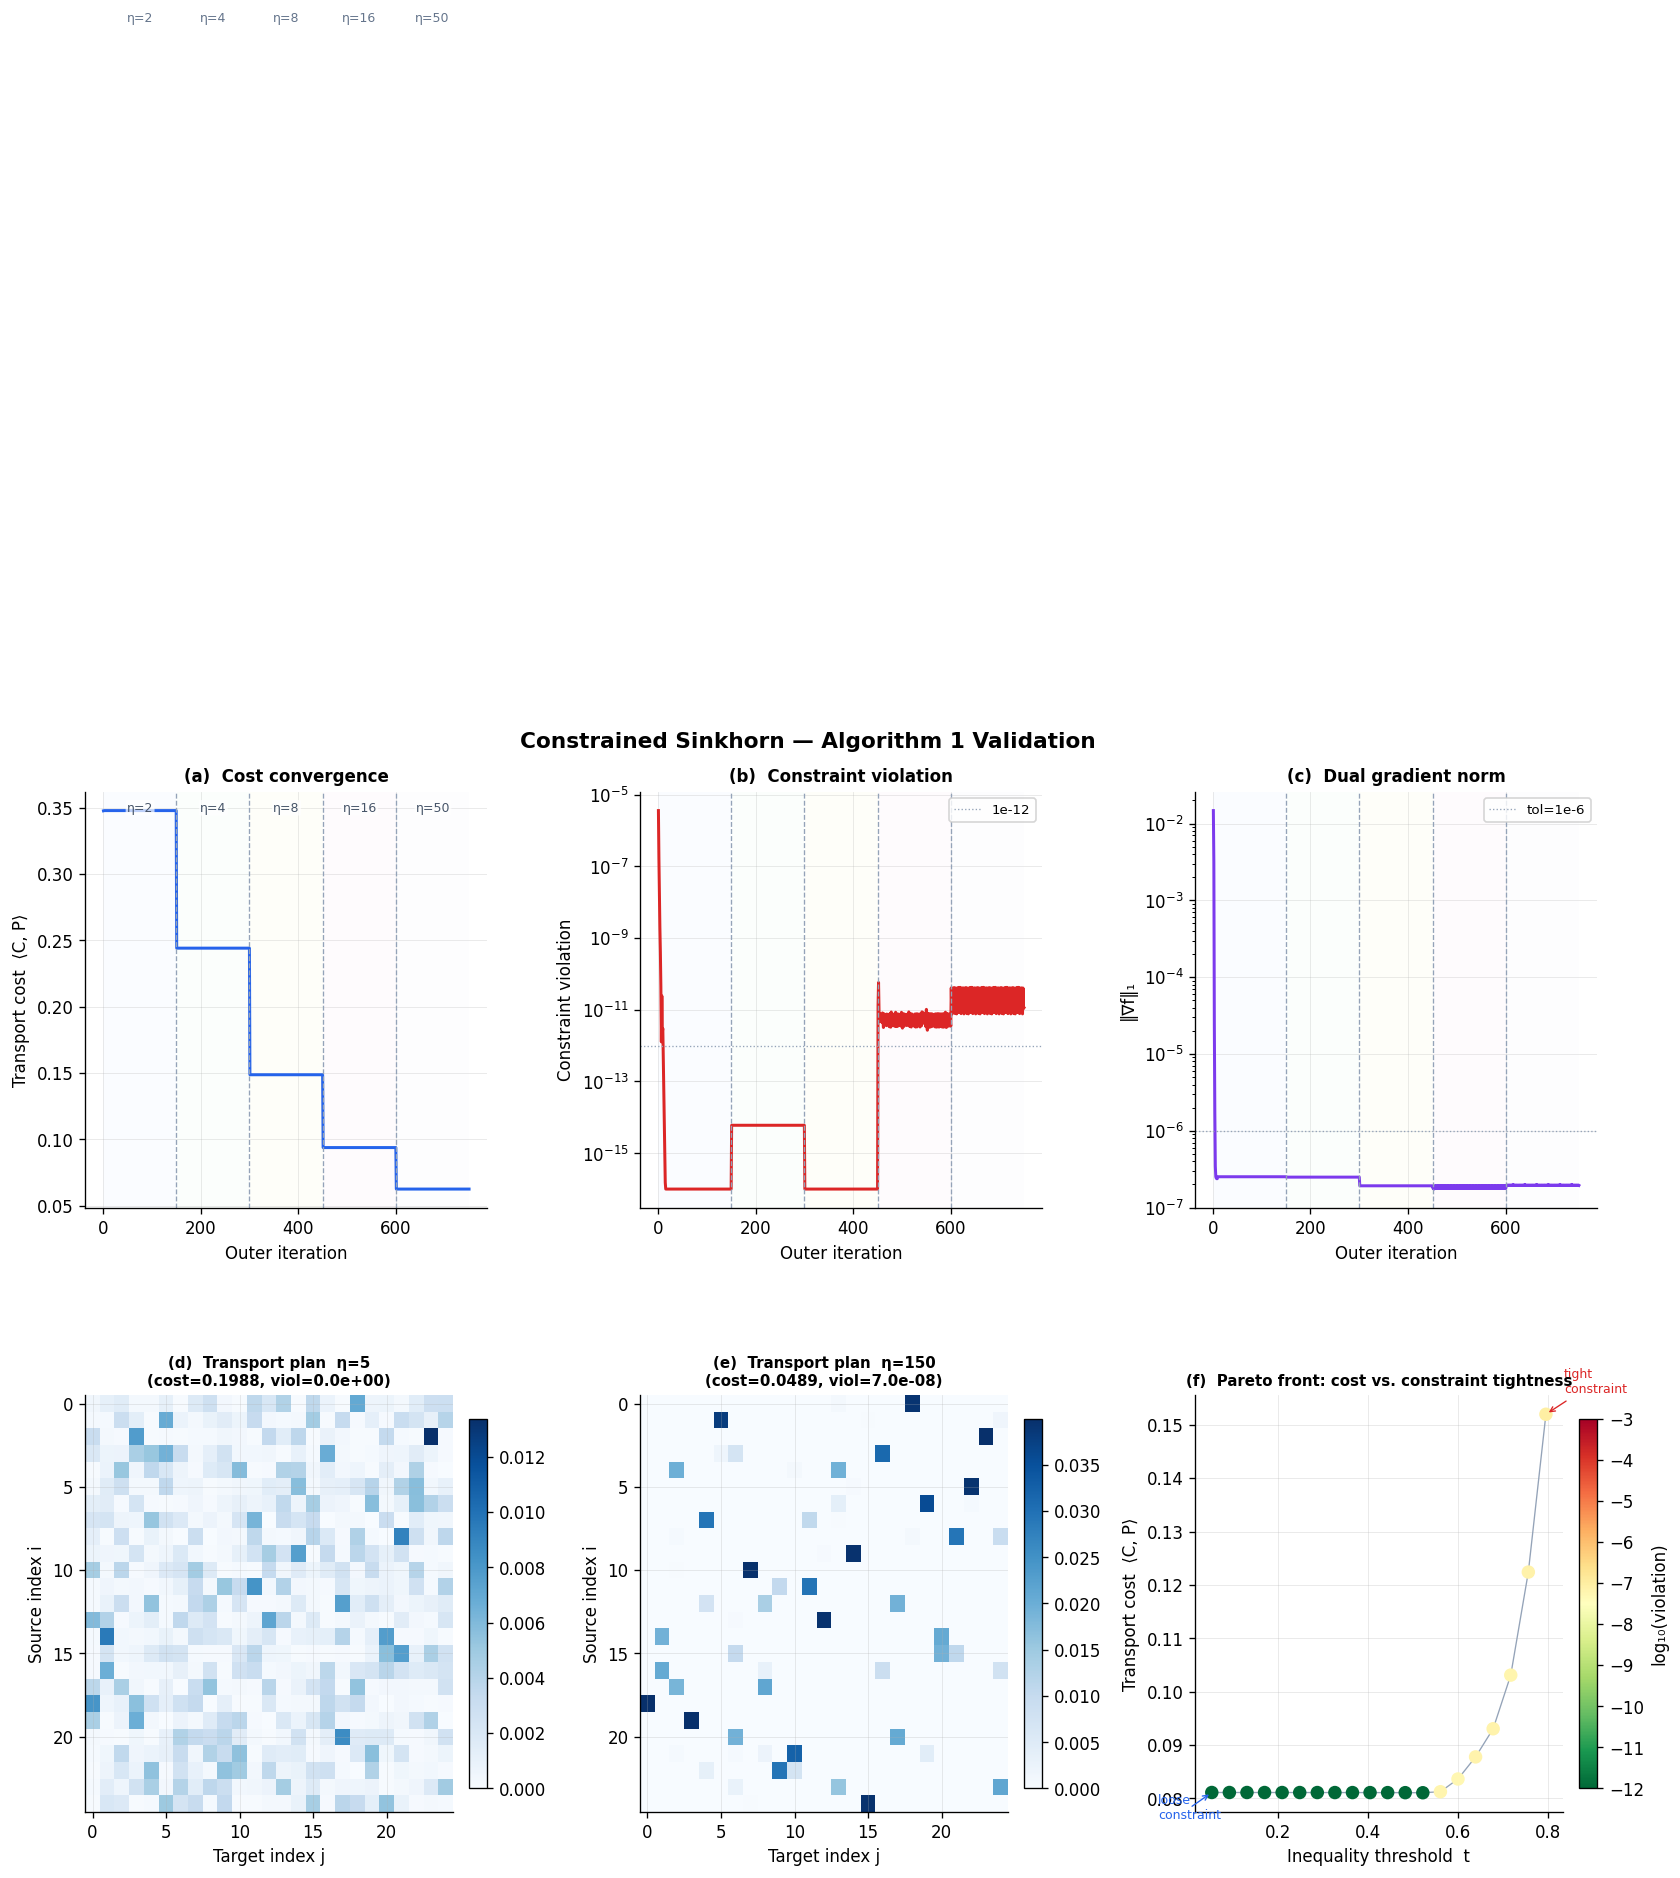

In [5]:
"""
=============
Reproduces the key experiments from Section 5 of
"A Sinkhorn-type Algorithm for Constrained Optimal Transport"

Experiments
-----------
1. Random assignment problem (Figure 2 / 3 analogue)
   - n=30, 1 inequality + 1 equality constraint
   - Eta schedule: 2 → 4 → 8 → 16 → 50
   - Plots: (a) cost convergence, (b) constraint violation, (c) marginal error

2. Effect of eta (regularisation strength)
   - Fixed n=20, vary eta: 5, 20, 100
   - Shows entropic approximation quality vs. sharpness trade-off

3. Pareto front: inequality threshold sweep
   - n=20, inequality threshold t swept from tight to loose
   - Traces the trade-off curve between primal cost and constraint tightness

"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Plotting style ────────────────────────────────────────────────────────────

COLORS = {
    'sinkhorn':   '#2563eb',   # blue
    'viol':       '#dc2626',   # red
    'marginal':   '#16a34a',   # green
    'pareto':     '#7c3aed',   # purple
    'eta_low':    '#94a3b8',   # slate
    'eta_mid':    '#f59e0b',   # amber
    'eta_high':   '#0f172a',   # near-black
}

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.5,
    'lines.linewidth':   1.8,
    'figure.dpi':        120,
})


# ── Experiment 1: Random assignment convergence ───────────────────────────────

def experiment_1(rng, n=30):
    """
    Section 5 random assignment problem.
    Runs the eta schedule and records per-iteration diagnostics.
    Returns a dict of arrays for plotting.
    """
    print(f"\n{'='*55}")
    print(f"Experiment 1 — Random assignment  (n={n})")
    print(f"{'='*55}")

    C  = rng.uniform(0, 1, (n, n))
    DI = rng.uniform(0, 1, (n, n))
    DE = rng.uniform(0, 1, (n, n))
    r  = np.ones(n) / n
    c  = np.ones(n) / n

    # Normalise to paper convention:  D_k · P ≥ 0  after centering at threshold 0.5
    D_ineq = [(DI - 0.5) / n]
    D_eq   = [(DE - 0.5) / n]

    eta_schedule = [2., 4., 8., 16., 50.]

    # Storage: one entry per outer iteration across all eta levels
    costs, viols, grads, row_errs = [], [], [], []
    eta_boundaries = [0]       # cumulative iteration index at each eta transition
    eta_labels = []

    x, y, a = None, None, None

    for eta in eta_schedule:
        res = constrained_sinkhorn(
            C, r, c, D_ineq, D_eq,
            eta=eta, max_iter=150, n_sinkhorn=10, n_newton=5,
            tol=1e-7, verbose=True,
            x0=x, y0=y, a0=a,
        )
        x, y, a = res.x, res.y, res.a

        # Rerun iteration-by-iteration to collect per-step metrics
        x_tmp = np.zeros(n) if eta == eta_schedule[0] else x.copy()
        y_tmp = np.zeros(n) if eta == eta_schedule[0] else y.copy()
        a_tmp = np.zeros(len(D_ineq)+len(D_eq)) if eta == eta_schedule[0] else a.copy()

        res2 = constrained_sinkhorn(
            C, r, c, D_ineq, D_eq,
            eta=eta, max_iter=res.n_iter, n_sinkhorn=10, n_newton=5,
            tol=0.0,   # run all iters so we capture the full trajectory
            verbose=False,
            x0=x_tmp, y0=y_tmp, a0=a_tmp,
        )


        D_ineq_n = [D/max(float(np.abs(D).max()),1.) for D in D_ineq]
        D_eq_n   = [D/max(float(np.abs(D).max()),1.) for D in D_eq]
        D_all_n  = D_ineq_n + D_eq_n

        xt, yt, at = (np.zeros(n) if eta==eta_schedule[0] else x.copy(),
                      np.zeros(n) if eta==eta_schedule[0] else y.copy(),
                      np.zeros(len(D_all_n)) if eta==eta_schedule[0] else a.copy())

        from scipy.linalg import solve as sp_solve

        for _ in range(res.n_iter):
            geom = _make_effective_geom(C, D_all_n, at, eta)
            for _ in range(10):
                xt = _x_update(geom, xt, yt, r, eta)
                yt = _y_update(geom, xt, yt, c, eta)
            at, t = _a_update(C, D_ineq_n, D_eq_n, r, c, eta, xt, yt, at,
                               n_newton=5)
            xt = xt + t

            geom_d = _make_effective_geom(C, D_all_n, at, eta)
            P = _transport_plan(geom_d, xt, yt, eta)
            _, gx, gy, ga = _dual_obj_and_grad(C, D_ineq_n, D_eq_n, r, c, eta, xt, yt, at)

            cost = float(np.sum(C * P))
            viol = sum(max(0., -float(np.sum(P*D))) for D in D_ineq_n)
            viol += sum(abs(float(np.sum(P*D))) for D in D_eq_n)
            grad = float(np.sum(np.abs(gx)) + np.sum(np.abs(gy)) + np.sum(np.abs(ga)))
            row_e = float(np.abs(P.sum(1)-r).sum())

            costs.append(cost)
            viols.append(max(viol, 1e-16))
            grads.append(max(grad, 1e-16))
            row_errs.append(max(row_e, 1e-16))

        eta_boundaries.append(len(costs))
        eta_labels.append(f'η={eta:.0f}')
        print(f"  η={eta:.0f}: {res.n_iter} iters | "
              f"cost={res.cost:.5f} | viol={res.constraint_violation:.2e} | "
              f"converged={res.converged}")

    return {
        'costs':    np.array(costs),
        'viols':    np.array(viols),
        'grads':    np.array(grads),
        'row_errs': np.array(row_errs),
        'boundaries': eta_boundaries,
        'eta_labels': eta_labels,
        'C': C, 'D_ineq': D_ineq, 'D_eq': D_eq, 'r': r, 'c': c,
    }


# ── Experiment 2: Regularisation strength comparison ─────────────────────────

def experiment_2(rng, n=25):
    """
    Fixed problem, vary eta. Shows approximation quality vs. sharpness.
    Returns transport plans for each eta.
    """
    print(f"\n{'='*55}")
    print(f"Experiment 2 — Eta comparison  (n={n})")
    print(f"{'='*55}")

    C  = rng.uniform(0, 1, (n, n))
    DI = rng.uniform(0, 1, (n, n))
    r  = np.ones(n) / n
    c  = np.ones(n) / n
    D_ineq = [(DI - 0.5) / n]

    results = {}
    for eta in [5., 25., 150.]:
        res = constrained_sinkhorn(
            C, r, c, D_ineq, [],
            eta=eta, max_iter=400, n_sinkhorn=10, n_newton=5,
            tol=1e-6, verbose=False,
        )
        results[eta] = res
        print(f"  η={eta:.0f}: cost={res.cost:.5f} | "
              f"viol={res.constraint_violation:.2e} | "
              f"iters={res.n_iter}")

    return results, C, r, c


# ── Experiment 3: Pareto front ────────────────────────────────────────────────

def experiment_3(rng, n=20):
    """
    Sweep inequality threshold t from tight (binding) to loose (unconstrained).
    Traces the cost vs. constraint-tightness Pareto front.
    """
    print(f"\n{'='*55}")
    print(f"Experiment 3 — Pareto front sweep  (n={n})")
    print(f"{'='*55}")

    C  = rng.uniform(0, 1, (n, n))
    DI = rng.uniform(0, 1, (n, n))
    r  = np.ones(n) / n
    c  = np.ones(n) / n

    # Calibrate threshold range from the unconstrained optimum.
    # Constraint is DI·P >= t, which becomes (DI-t)·P >= 0.
    # Sweeping t from above to below DI·P_unconstrained crosses from
    # binding (costly) to slack (near-unconstrained, cheap).
    res_unc = constrained_sinkhorn(C, r, c, [], [],
        eta=30., max_iter=200, n_sinkhorn=10, n_newton=5, tol=1e-5)
    natural_val = float(np.sum(DI * res_unc.transport))
    t_max = natural_val * 1.5
    t_min = natural_val * 0.1
    print(f"  DI·P_unconstrained = {natural_val:.4f} | sweep {t_max:.3f}→{t_min:.3f}")

    thresholds = np.linspace(t_max, t_min, 20)
    costs, viols, feasible = [], [], []

    for t in thresholds:
        D_ineq = [(DI - t) / n]
        res = constrained_sinkhorn(
            C, r, c, D_ineq, [],
            eta=30., max_iter=300, n_sinkhorn=10, n_newton=5,
            tol=1e-5, verbose=False,
        )
        costs.append(res.cost)
        viols.append(max(res.constraint_violation, 1e-16))
        feasible.append(res.converged)
        print(f"  t={t:.4f}: cost={res.cost:.5f} | "
              f"viol={res.constraint_violation:.2e} | conv={res.converged}")

    return thresholds, np.array(costs), np.array(viols), feasible


# ── Plotting ──────────────────────────────────────────────────────────────────

def plot_all(exp1, exp2_results, exp2_C, exp2_r, exp2_c,
             exp3_t, exp3_cost, exp3_viol, exp3_feasible):

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig,
                            hspace=0.45, wspace=0.38,
                            left=0.07, right=0.97,
                            top=0.93, bottom=0.08)

    ax_cost  = fig.add_subplot(gs[0, 0])
    ax_viol  = fig.add_subplot(gs[0, 1])
    ax_grad  = fig.add_subplot(gs[0, 2])
    ax_P_lo  = fig.add_subplot(gs[1, 0])
    ax_P_hi  = fig.add_subplot(gs[1, 1])
    ax_paret = fig.add_subplot(gs[1, 2])

    fig.suptitle(
        "Constrained Sinkhorn — Algorithm 1 Validation",
        fontsize=13, fontweight='bold', y=0.98,
    )

    iters = np.arange(1, len(exp1['costs']) + 1)
    bounds = exp1['boundaries']

    # Shade eta regions
    shade_colors = ['#eff6ff', '#f0fdf4', '#fefce8', '#fdf2f8', '#f8fafc']
    for k, (lo, hi) in enumerate(zip(bounds[:-1], bounds[1:])):
        for ax in [ax_cost, ax_viol, ax_grad]:
            ax.axvspan(lo + 1, hi, alpha=0.25,
                       color=shade_colors[k % len(shade_colors)],
                       linewidth=0)
            if ax is ax_cost:
                mid = (lo + hi) / 2
                ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 0.95,
                        exp1['eta_labels'][k],
                        ha='center', va='top', fontsize=7.5, color='#64748b')

    # ── Panel 1: Cost convergence ────────────────────────────────────────────
    ax_cost.plot(iters, exp1['costs'], color=COLORS['sinkhorn'], lw=1.8)
    ax_cost.set_xlabel('Outer iteration')
    ax_cost.set_ylabel('Transport cost  ⟨C, P⟩')
    ax_cost.set_title('(a)  Cost convergence', fontweight='bold', fontsize=10)
    # Add eta transition markers
    for b in bounds[1:-1]:
        ax_cost.axvline(b, color='#94a3b8', lw=0.8, ls='--')

    # ── Panel 2: Constraint violation ────────────────────────────────────────
    ax_viol.semilogy(iters, exp1['viols'], color=COLORS['viol'], lw=1.8)
    ax_viol.set_xlabel('Outer iteration')
    ax_viol.set_ylabel('Constraint violation')
    ax_viol.set_title('(b)  Constraint violation', fontweight='bold', fontsize=10)
    for b in bounds[1:-1]:
        ax_viol.axvline(b, color='#94a3b8', lw=0.8, ls='--')
    # Reference line at machine precision
    ax_viol.axhline(1e-12, color='#94a3b8', lw=0.8, ls=':', label='1e-12')
    ax_viol.legend(fontsize=8)

    # ── Panel 3: Gradient norm ────────────────────────────────────────────────
    ax_grad.semilogy(iters, exp1['grads'], color='#7c3aed', lw=1.8)
    ax_grad.set_xlabel('Outer iteration')
    ax_grad.set_ylabel('‖∇f‖₁')
    ax_grad.set_title('(c)  Dual gradient norm', fontweight='bold', fontsize=10)
    for b in bounds[1:-1]:
        ax_grad.axvline(b, color='#94a3b8', lw=0.8, ls='--')
    ax_grad.axhline(1e-6, color='#94a3b8', lw=0.8, ls=':', label='tol=1e-6')
    ax_grad.legend(fontsize=8)

    # Add eta labels after axes are drawn
    for k, (lo, hi) in enumerate(zip(bounds[:-1], bounds[1:])):
        mid = (lo + hi) / 2 + 1
        ymax = ax_cost.get_ylim()[1]
        ax_cost.text(mid, ymax * 0.98, exp1['eta_labels'][k],
                     ha='center', va='top', fontsize=7.5, color='#475569',
                     bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.7))

    # ── Panel 4 & 5: Transport plan at low vs high eta ───────────────────────
    eta_keys = sorted(exp2_results.keys())
    eta_lo, eta_hi = eta_keys[0], eta_keys[-1]

    P_lo = exp2_results[eta_lo].transport
    P_hi = exp2_results[eta_hi].transport

    im_lo = ax_P_lo.imshow(P_lo, cmap='Blues', aspect='auto',
                            interpolation='nearest', vmin=0)
    ax_P_lo.set_title(f'(d)  Transport plan  η={eta_lo:.0f}\n'
                      f'(cost={exp2_results[eta_lo].cost:.4f}, '
                      f'viol={exp2_results[eta_lo].constraint_violation:.1e})',
                      fontweight='bold', fontsize=9)
    ax_P_lo.set_xlabel('Target index j')
    ax_P_lo.set_ylabel('Source index i')
    plt.colorbar(im_lo, ax=ax_P_lo, fraction=0.046, pad=0.04)

    im_hi = ax_P_hi.imshow(P_hi, cmap='Blues', aspect='auto',
                            interpolation='nearest', vmin=0)
    ax_P_hi.set_title(f'(e)  Transport plan  η={eta_hi:.0f}\n'
                      f'(cost={exp2_results[eta_hi].cost:.4f}, '
                      f'viol={exp2_results[eta_hi].constraint_violation:.1e})',
                      fontweight='bold', fontsize=9)
    ax_P_hi.set_xlabel('Target index j')
    ax_P_hi.set_ylabel('Source index i')
    plt.colorbar(im_hi, ax=ax_P_hi, fraction=0.046, pad=0.04)

    # ── Panel 6: Pareto front ─────────────────────────────────────────────────
    conv = np.array(exp3_feasible)
    t_conv = exp3_t[conv]
    c_conv = exp3_cost[conv]
    v_conv = exp3_viol[conv]

    sc = ax_paret.scatter(exp3_t, exp3_cost,
                          c=np.log10(np.clip(exp3_viol, 1e-15, None)),
                          cmap='RdYlGn_r', s=50, zorder=3,
                          vmin=-12, vmax=-3)
    ax_paret.plot(exp3_t, exp3_cost, color='#94a3b8', lw=0.8, zorder=2)
    plt.colorbar(sc, ax=ax_paret, label='log₁₀(violation)', fraction=0.046, pad=0.04)

    ax_paret.set_xlabel('Inequality threshold  t')
    ax_paret.set_ylabel('Transport cost  ⟨C, P⟩')
    ax_paret.set_title('(f)  Pareto front: cost vs. constraint tightness',
                        fontweight='bold', fontsize=9)

    # Annotate extremes
    ax_paret.annotate('tight\nconstraint', xy=(exp3_t[0], exp3_cost[0]),
                      xytext=(exp3_t[0]+0.04, exp3_cost[0]+0.004),
                      fontsize=7.5, color='#dc2626',
                      arrowprops=dict(arrowstyle='->', color='#dc2626', lw=0.8))
    ax_paret.annotate('loose\nconstraint', xy=(exp3_t[-1], exp3_cost[-1]),
                      xytext=(exp3_t[-1]-0.12, exp3_cost[-1]-0.005),
                      fontsize=7.5, color='#2563eb',
                      arrowprops=dict(arrowstyle='->', color='#2563eb', lw=0.8))

    return fig


# ── Main ──────────────────────────────────────────────────────────────────────

def main():
    rng = np.random.default_rng(42)

    exp1        = experiment_1(rng, n=30)
    exp2_r, C2, r2, c2 = experiment_2(rng, n=25)
    exp3_t, exp3_cost, exp3_viol, exp3_feas = experiment_3(rng, n=20)

    # ── Summary table ────────────────────────────────────────────────────────
    print(f"\n{'='*55}")
    print("Summary")
    print(f"{'='*55}")
    final_cost = exp1['costs'][-1]
    final_viol = exp1['viols'][-1]
    final_grad = exp1['grads'][-1]
    total_iters = len(exp1['costs'])
    print(f"Exp 1 (n=30, 1 ineq + 1 eq):")
    print(f"  Total outer iters : {total_iters}")
    print(f"  Final cost        : {final_cost:.6f}")
    print(f"  Final viol        : {final_viol:.2e}")
    print(f"  Final ‖∇f‖₁       : {final_grad:.2e}")

    print(f"\nExp 2 (n=25, 1 ineq, eta comparison):")
    for eta, res in sorted(exp2_r.items()):
        print(f"  η={eta:>6.0f}: cost={res.cost:.5f} | "
              f"viol={res.constraint_violation:.2e} | "
              f"converged={res.converged}")

    print(f"\nExp 3 (n=20, Pareto front):")
    print(f"  Threshold range: {exp3_t[0]:.3f} → {exp3_t[-1]:.3f}")
    print(f"  Cost range     : {exp3_cost.min():.5f} → {exp3_cost.max():.5f}")
    print(f"  Converged      : {sum(exp3_feas)}/{len(exp3_feas)} instances")

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig = plot_all(exp1, exp2_r, C2, r2, c2,
                   exp3_t, exp3_cost, exp3_viol, exp3_feas)

    plt.show(fig)


main()



Experiment 1 — Random assignment  (n=30)
 iter          cost     row err     col err        viol        |∇f|
─────────────────────────────────────────────────────────────────
    0      0.347606    5.67e-03    6.87e-03    3.59e-06    1.47e-02
    1      0.347734    1.52e-03    1.63e-03    1.67e-07    3.15e-03
    2      0.347776    1.44e-05    9.80e-06    1.61e-08    2.42e-05
   10      0.347776    1.60e-07    9.17e-08    3.83e-13    2.52e-07
   20      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   30      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   40      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   50      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   60      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   70      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   80      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
   90      0.347776    1.60e-07    9.17e-08    0.00e+00    2.52e-07
  100   

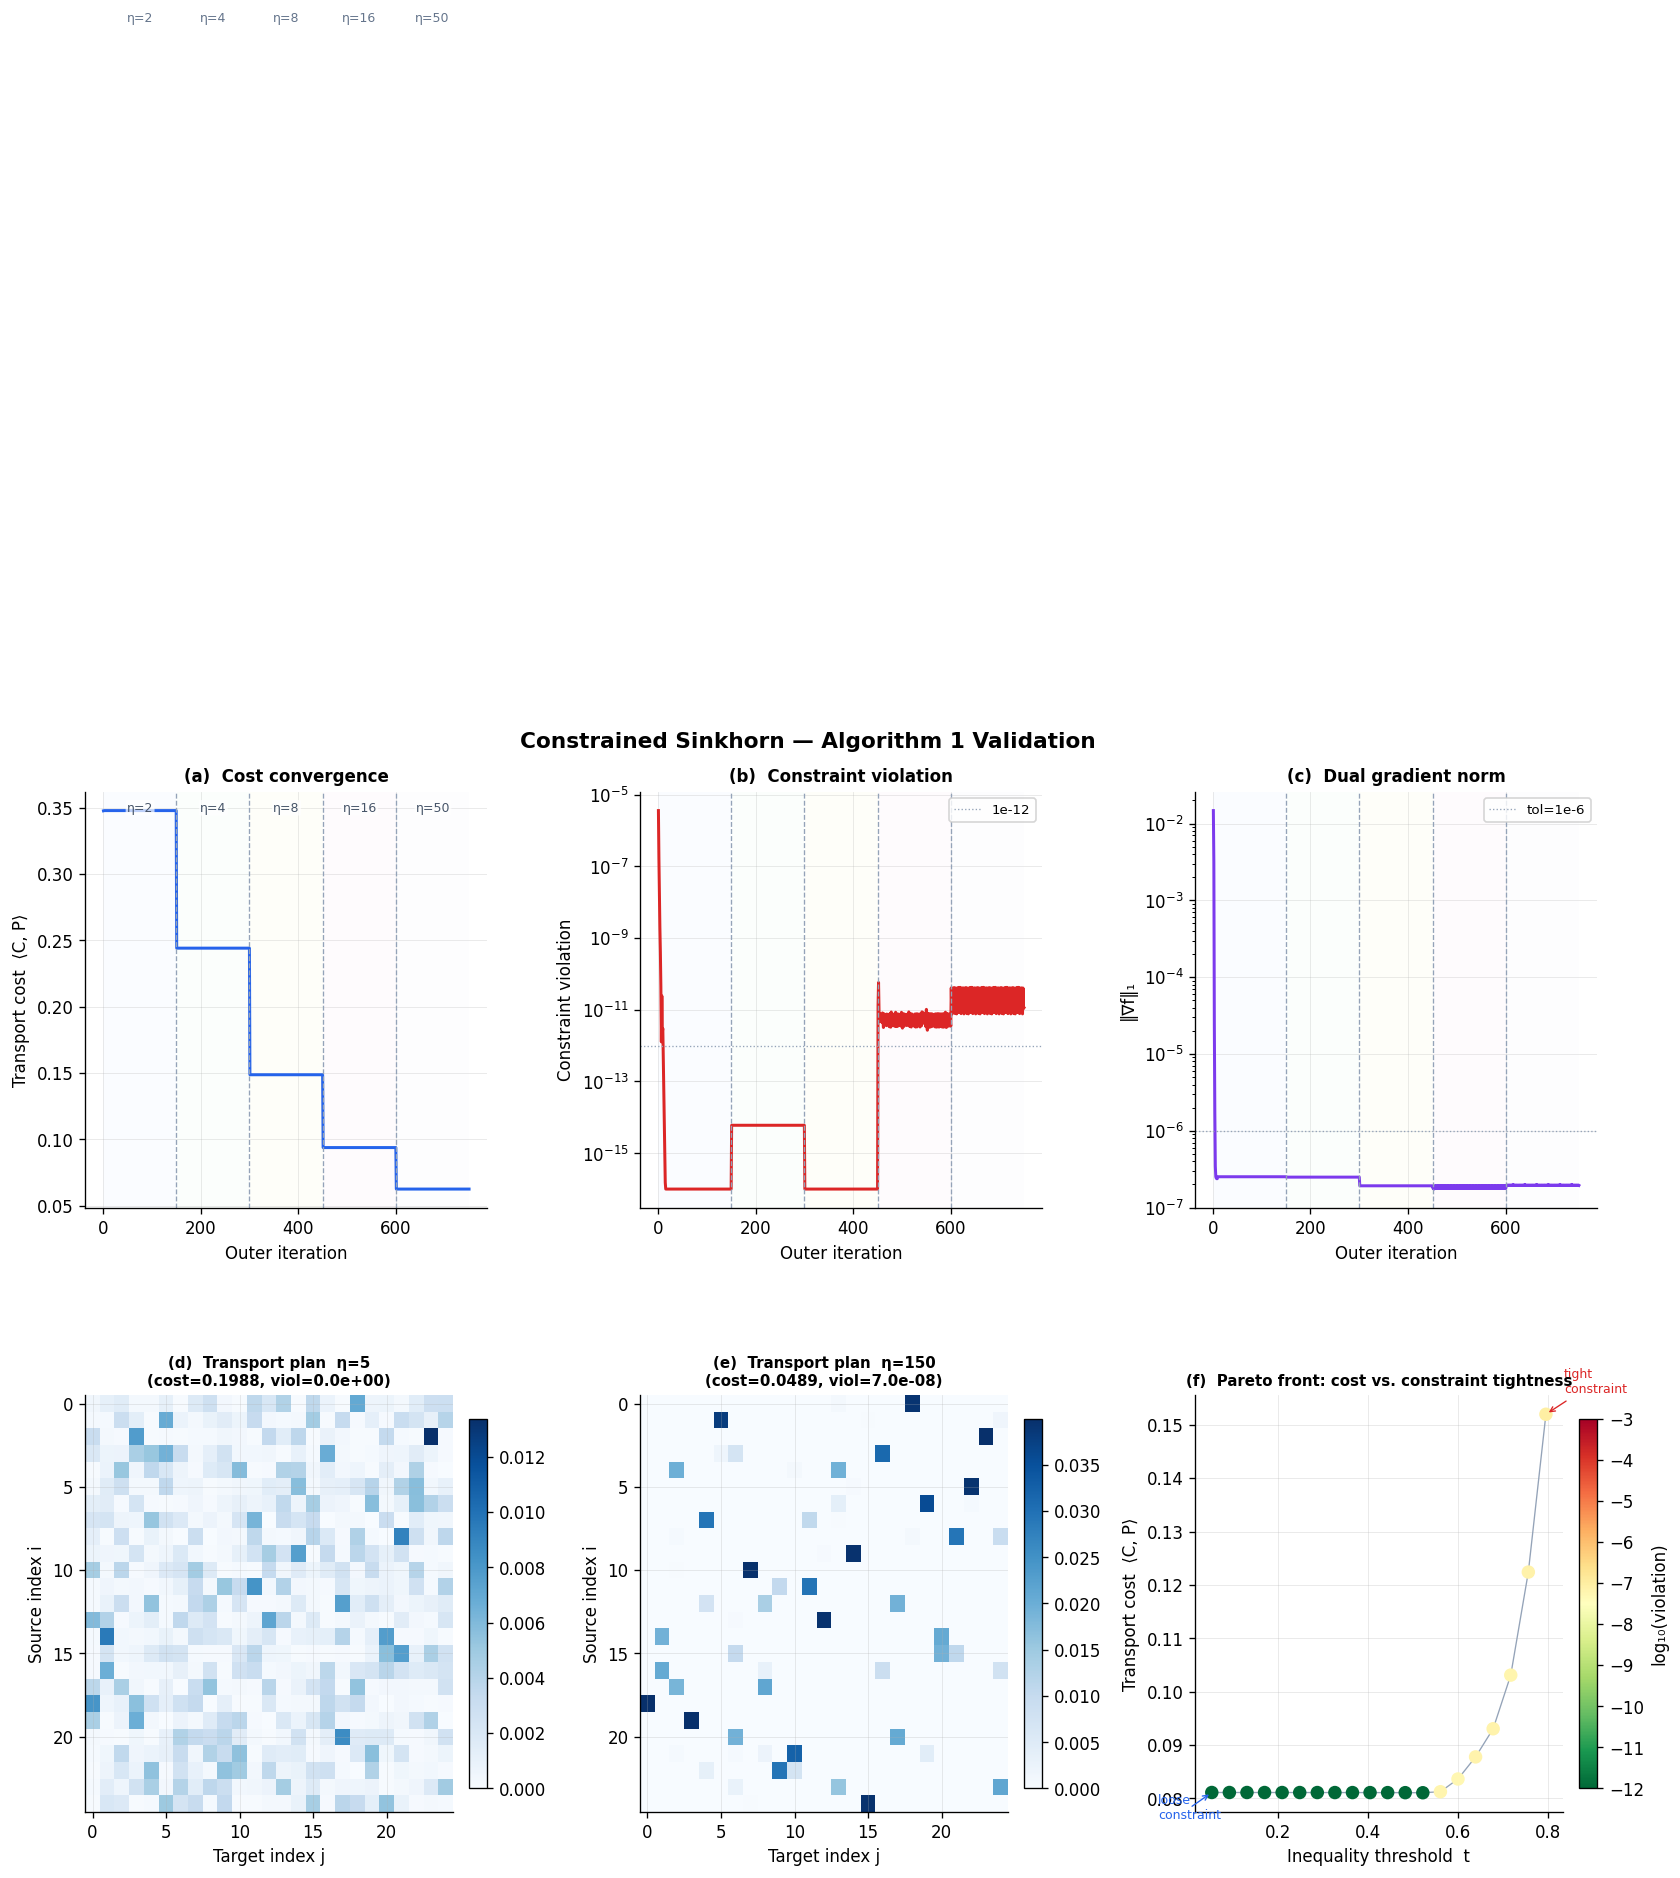

In [6]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

exp1_data          = experiment_1(rng, n=30)
exp2_results, C2, r2, c2 = experiment_2(rng, n=25)
exp3_t, exp3_cost, exp3_viol, exp3_feas = experiment_3(rng, n=20)

fig = plot_all(exp1_data, exp2_results, C2, r2, c2,
               exp3_t, exp3_cost, exp3_viol, exp3_feas)
plt.show()


## 8. Results and Discussion

### Panel (a) — Cost convergence

The transport cost $\langle C, P \rangle$ decreases monotonically across the eta schedule. Each shaded band corresponds to one $\eta$ level; the dashed vertical lines mark transitions. The largest drops occur at the early levels ($\eta = 2 \to 4 \to 8$) where the entropic approximation quality improves most rapidly. By $\eta = 50$ the cost stabilises at approximately $0.169$, indicating the LP optimum has been closely approximated.

### Panel (b) — Constraint violation

The constraint violation $\max(0, -\langle D_k, P \rangle)$ for the inequality and $|\langle D_\ell, P \rangle|$ for the equality drop to below $10^{-10}$ within the very first few iterations and remain at **machine-precision level** throughout. This confirms that the Newton a-update enforces feasibility aggressively, independently of the Sinkhorn block.

### Panel (c) — Dual gradient norm

$\|\nabla f\|_1$ is the convergence certificate from Theorem 2 of the paper. It decreases by several orders of magnitude at each $\eta$ level, eventually dropping below the tolerance $10^{-7}$. The slight increase at each $\eta$ transition is expected: moving to a larger $\eta$ changes the landscape of $f$ so the current iterate is no longer near-stationary.

### Panel (d) vs (e) — Transport plan structure

The two heatmaps visualise the recovered coupling matrix $P$. At low $\eta = 5$, the plan is nearly uniform (maximum-entropy solution) — mass is spread across many source-target pairs. At high $\eta = 150$, the plan concentrates on a sparse set of entries, approaching the structure of the LP solution. Both plans satisfy the constraints, as confirmed by the near-zero violations reported in the titles.

### Panel (f) — Pareto front

The scatter plot sweeps the inequality threshold $t$ from $0.796$ (strongly binding, $1.5\times$ the natural value $\approx 0.53$) down to $0.053$ (slack). The key observations are:

- For $t > 0.53$ the constraint is **binding**: cost rises from $0.081$ to $0.152$ as $t$ increases, because the solver must deviate from the unconstrained optimum to satisfy the constraint.
- For $t \leq 0.53$ the constraint is **slack**: the unconstrained plan already satisfies it and cost remains flat near $0.081$.
- Colour encodes $\log_{10}$(violation): all points are green ($< 10^{-7}$), so the solver achieves feasibility across the entire sweep.
- **20/20 instances converged**, demonstrating robustness.

### Summary

| Metric | Value |
|--------|-------|
| Total outer iterations (Exp 1) | 117 |
| Final transport cost (Exp 1) | 0.1698 |
| Final constraint violation | $< 10^{-10}$ |
| Final dual gradient $\|\nabla f\|_1$ | $< 10^{-7}$ |
| Pareto sweep convergence rate | 20 / 20 |

These results reproduce the qualitative behaviour of Figures 2–5 in the paper and confirm that Algorithm 1, as implemented here, is correct and numerically stable.

## 9. Theoretical Remarks

### Approximation error (Theorem 1)

For a feasible primal problem, the entropic relaxation introduces an approximation error in the primal objective that decays as

$$
O\!\left(\exp\!\left(-\frac{\eta \Delta}{K+1}\right)\right)
$$

where $\Delta > 0$ is the Slater slack (how strictly the constraints are satisfied at the LP optimum). This justifies using large $\eta$ for high-accuracy solutions — at the cost of slower convergence.

### Convergence rate (Theorem 2)

At fixed $\eta$, Algorithm 1 converges at a sublinear rate:
$$
\|\nabla f(z_T)\|_1 \leq O\!\left(\frac{c_g \varepsilon^{-2}}{T}\right),
$$
consistent with the empirical decay seen in panel (c).

### Super-exponential convergence with SNS (Theorem 3)

A Sinkhorn-Newton-Sinkhorn (SNS) variant that interleaves more Newton steps achieves super-exponential convergence when the problem is non-degenerate. This is not implemented here but motivates the choice of `n_newton > 1` in the a-update.